In [1]:
# 커널 확인
print("hello")

hello


# lenet 5 구현하기

In [2]:
# lenet5 구현하기
# lib import
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [3]:
data_transform = transforms.Compose([
    transforms.ToTensor(), # 이미지를 텐서로 변환
    transforms.Resize((32, 32)), # 이미지 크기를 32x32로 조정 (lenet5 입력 크기에 맞추기)
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST 데이터셋의 평균과 표준편차로 정규화
])
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=data_transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=data_transform)
mnist_train



Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [4]:
# 이미지 전처리, 셔플링, 배치 조정
from torch.utils.data import DataLoader
train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True) # 배치 크기 64로 설정, 데이터 셔플
test_loader = DataLoader(mnist_test, batch_size=64, shuffle=False) # 테스트 데이터는 섞지 않음


In [5]:
# 데이터 확인 (배치 크기, 채널 수, 가로, 세로)
next(iter(train_loader))[0].shape # train_loader에서 첫 번째 배치를 가져와서 확인

torch.Size([64, 1, 32, 32])

In [6]:
class LeNet5(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=0)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        x = torch.flatten(x, 1)  # (N, 16*5*5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [7]:
# 모델 인스턴스 생성
model = LeNet5()

# Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [8]:
# torchsummary 실행
from torchsummary import summary
summary(model, input_size=(1, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             156
            Conv2d-2           [-1, 16, 10, 10]           2,416
            Linear-3                  [-1, 120]          48,120
            Linear-4                   [-1, 84]          10,164
            Linear-5                   [-1, 10]             850
Total params: 61,706
Trainable params: 61,706
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.24
Estimated Total Size (MB): 0.29
----------------------------------------------------------------


In [9]:
# optimizer와 loss function 정의
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
epochs = 20

In [10]:
'''
# 저장된 모델 불러오기, 새로운 모델(lenet_new) 생성 후 가중치 불러오기
model = LeNet5()
model.load_state_dict(torch.load('lenet5_mnist.pth'))
model.to(device)
'''

"\n# 저장된 모델 불러오기, 새로운 모델(lenet_new) 생성 후 가중치 불러오기\nmodel = LeNet5()\nmodel.load_state_dict(torch.load('lenet5_mnist.pth'))\nmodel.to(device)\n"

In [11]:
# 모델 학습, tqdm으로 진행 상황 표시, tenseboard로 손실 기록
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter(log_dir='./runs/lenet5')
count = 0
from tqdm import tqdm

# 체크포인트 불러오기
'''
checkpoint = torch.load('lenet5_checkpoint.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']
'''

for epoch in range(epochs):
    model.train()
    total_loss = 0
    train_loader = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', unit='batch')
    for batch_idx, (data, target) in enumerate(tqdm(train_loader)):
        data, target = data.to(device), target.to(device) # 데이터를 GPU로 이동
        optimizer.zero_grad() # 기울기 초기화
        output = model(data) # 모델에 입력 데이터 전달하여 예측값 계산
        loss = criterion(output, target) # 예측값과 실제 레이블 간의 손실 계산
        loss.backward() # 역전파를 통해 기울기 계산
        optimizer.step() # 가중치 업데이트
        train_loader.set_description(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}') # tqdm에 현재 배치 손실 표시
        total_loss += loss.item() # 배치 손실을 총 손실에 누적
        writer.add_scalar('Loss/Batch', loss.item(), count) # TensorBoard에 배치 손실 기록
        count += 1
    # 체크포인트 여기에 저장
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss.item(),
    }, 'lenet5_checkpoint.pth')
    # validation 단계에서 모델 평가 및 손실 계산
    avg_loss = total_loss / len(train_loader) # 평균 손실 계산
    print(f'Epoch: {epoch+1}, Loss: {avg_loss:.4f}')

100%|██████████| 938/938 [00:26<00:00, 35.60it/s]


Epoch: 1, Loss: 0.2234


100%|██████████| 938/938 [00:27<00:00, 34.04it/s]


Epoch: 2, Loss: 0.0607


100%|██████████| 938/938 [00:28<00:00, 33.39it/s]


...

Epoch: 18, Loss: 0.0077


100%|██████████| 938/938 [00:25<00:00, 36.12it/s]


Epoch: 19, Loss: 0.0065


100%|██████████| 938/938 [00:27<00:00, 33.72it/s]


Epoch: 20, Loss: 0.0078


In [12]:
# 모델 평가
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
print(f'Accuracy: {100 * correct / total:.2f}%')


Accuracy: 98.84%


In [13]:
F.softmax(output, dim=1)

tensor([[3.4794e-12, 1.0000e+00, 6.4086e-09, 1.6909e-15, 2.1114e-08, 8.6421e-11,
         1.7751e-10, 2.0041e-08, 3.9210e-10, 1.8656e-11],
        [1.6535e-13, 1.2115e-14, 1.0000e+00, 4.1510e-13, 1.8474e-21, 4.3047e-21,
         9.4702e-15, 6.3562e-13, 1.6975e-13, 4.1603e-19],
        [4.1361e-23, 1.0305e-15, 5.8710e-18, 1.0000e+00, 1.1975e-26, 1.2092e-14,
         1.6967e-19, 8.1926e-19, 2.2181e-17, 7.4850e-17],
        [9.2032e-18, 8.0189e-17, 3.7723e-16, 3.8411e-23, 1.0000e+00, 3.8522e-16,
         4.4981e-19, 1.0463e-17, 7.0877e-17, 4.9674e-13],
        [7.6701e-22, 3.9146e-20, 3.9448e-24, 8.6738e-14, 2.8759e-25, 1.0000e+00,
         8.9675e-16, 3.7264e-26, 1.1612e-13, 1.4233e-17],
        [1.1126e-10, 2.0599e-24, 1.7724e-17, 8.2513e-21, 7.2218e-17, 1.8221e-13,
         1.0000e+00, 2.5546e-26, 1.1571e-13, 3.9058e-19],
        [1.0234e-12, 6.6246e-08, 2.1622e-07, 3.8655e-07, 1.8802e-08, 6.8663e-13,
         4.6453e-14, 1.0000e+00, 7.3882e-11, 3.9287e-09],
        [1.5328e-18, 7.7207

# 모델 저장하기 1

In [ ]:
# 모델 저장(가중치만 저장)
torch.save(model.state_dict(), 'lenet5_mnist.pth')


In [ ]:
# 저장된 모델 불러오기, 새로운 모델(lenet_new) 생성 후 가중치 불러오기
lenet_new = LeNet5()
lenet_new.load_state_dict(torch.load('lenet5_mnist.pth'))
# lenet_new.to(device)


# 모델 저장하기 2

In [ ]:
# 모델 저장 2 (모델 구조까지 포함, 통째로)
torch.save(model, 'lenet5_full.pth')

In [ ]:
'''
# ./lenet_full.pth 파일을 불러오기
import torch

class LeNet5(torch.nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()

    def forward(self, x):
        return x

model = torch.load('lenet5_full.pth', weights_only=False)
print(model)
'''

# 모델 저장하기 3

In [ ]:
# 모델 저장 (체크포인트 활용)
torch.save({
    'epoch': epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss,
}, 'lenet5_checkpoint.pth')


In [ ]:
# 불러올 때
checkpoint = torch.load('lenet5_checkpoint.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']

# 이미지 인식하여 분류하기

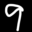

In [49]:
# ./data/4.png 이미지 인식
from PIL import Image
import torchvision.transforms as transforms
# 이미지 불러오기
image_path = './data/inf-9.png'
image = Image.open(image_path).convert('L') # 흑백 이미지로 변환

#이미지 색 반전
image = transforms.functional.invert(image)

# 이미지 크기를 32x32로 조정
transform = transforms.Compose([
    transforms.Resize((32, 32)),
])
image = transform(image)

image


In [50]:
import numpy as np
image_np = np.array(image)
image_np.shape

(32, 32)

추론할 때의 전처리는 학습할 때의 전처리와 동일하게 해야 한다.
- 텐서로 변환
- 모델 입력 크기에 맞게 조정
- 정규화

In [51]:
# 이미지 전처리
transform = transforms.Compose([
    transforms.Resize((32, 32)), # 이미지 크기를 32x32로 조정
    transforms.ToTensor(), # 이미지를 텐서로 변환
    transforms.Grayscale(num_output_channels=1), # 흑백 이미지로 변환
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST 데이터셋의 평균과 표준편차로 정규화
])
image = transform(image).unsqueeze(0).to(device) # 배치 차원 추가 및 GPU로 이동
image


tensor([[[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]]],
       device='cuda:0')

In [52]:
# 모델 예측
model.eval()
with torch.no_grad():
    output = model(image)
    print(nn.Softmax(output))
    predicted = torch.argmax(output, dim=1).item()
print(f'Predicted digit: {predicted}')


Softmax(
  dim=tensor([[-18.5146,  -6.4300,  -7.2915, -17.1589,   3.2606, -15.8389, -25.5172,
            11.1528,  -3.6881,   5.0812]], device='cuda:0')
)
Predicted digit: 7
